In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:

image_matching_challenge_2025_path = kagglehub.competition_download('image-matching-challenge-2025')

print('Data source import complete.')


100%|██████████| 4.84G/4.84G [00:22<00:00, 227MB/s]

Extracting files...


Data source import complete.


In [ ]:
dataset_path = image_matching_challenge_2025_path  # This is the correct path


In [ ]:
import os

# Check if the path exists and list files
if os.path.exists(dataset_path):
    print("Files in dataset path:")
    print(os.listdir(dataset_path))
else:
    print("Dataset path does not exist:", dataset_path)


Files in dataset path:
['train', 'train_thresholds.csv', 'train_labels.csv', 'test', 'sample_submission.csv']





The dataset contains:
* train/ → Training images (labeled with scenes)
* test/ → Test images (we need to predict scene clusters & camera poses)
* train_thresholds.csv → Provides similarity thresholds for deciding if two images match.
* train_labels.csv → Defines which images belong to the same scene in the training set.
* sample_submission.csv → Shows the required submission format.

Let's focus on the training dataset for now.
For Example: Open the "imc2024_lizard_pond" subfolder in the training dataset.
we'll find images with different naming patterns:

* "lizard_X" → Images of the lizard scene
* "pond_X" → Images of the pond scene3)
* "outliers_img_X" → Irrelevant images that don’t belong to the lizard or pond


# **EXPLORATORY DATA ANALYSIS**

The first and most crucial step for anything involving data- EDA!

In [ ]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
import pandas as pd
import os

# Use the correct path where your files are extracted
dataset_path = image_matching_challenge_2025_path
# Load CSV
train_labels = pd.read_csv(os.path.join(dataset_path, 'train_labels.csv'))

# Display first few rows
train_labels.head()


,dataset,scene,image,rotation_matrix,translation_vector
0,imc2023_haiper,fountain,fountain_image_116.png,0.122655949;0.947713775;-0.294608417;0.1226706...,0.093771314;-0.803560988;2.062001533
1,imc2023_haiper,fountain,fountain_image_108.png,0.474305910;0.359108654;-0.803787832;0.2888416...,0.358946647;-0.797557548;1.910906929
2,imc2023_haiper,fountain,fountain_image_101.png,0.565115476;-0.138485064;-0.813305838;0.506678...,0.146922468;-0.981392596;2.009002852
3,imc2023_haiper,fountain,fountain_image_082.png,-0.308320392;-0.794654112;0.522937261;0.948141...,0.206413831;-1.174321103;3.667167680
4,imc2023_haiper,fountain,fountain_image_071.png,-0.569002830;-0.103808175;0.815757098;0.778745...,-0.015140892;-1.334052012;3.488936597


In [ ]:
# Check dataset info (column names, data types, missing values)
train_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1945 entries, 0 to 1944
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   dataset             1945 non-null   object
 1   scene               1945 non-null   object
 2   image               1945 non-null   object
 3   rotation_matrix     1945 non-null   object
 4   translation_vector  1945 non-null   object
dtypes: object(5)
memory usage: 76.1+ KB


Each row of train_labels. csv file represents one image and gives us:

1) dataset → The dataset name it belongs to (e.g., imc2023_haiper).

2) scene → The scene category (e.g., all images with fountain are from the same place).

3) image → The filename of the image.

4) rotation_matrix → Camera rotation matrix (used to determine the angle of capture).

5) translation_vector → Camera translation vector (used to determine the position shift).




In [ ]:

#  Number of unique scenes
num_scenes = train_labels["scene"].nunique()
num_scenes

30

In [ ]:
#  Count images per scene
scene_counts = train_labels["scene"].value_counts()
scene_counts

,count
scene,
peach,200
dioscuri,140
outliers,122
st_peters_square,100
grand_place_brussels,100
st_pauls_cathedral,100
lizard,90
pond,90
vineyard_split_3,85


In [ ]:

# Number of unique datasets
num_datasets = train_labels["dataset"].nunique()
num_datasets

13

In [ ]:
# Count images per dataset
dataset_counts = train_labels["dataset"].value_counts()
dataset_counts

,count
dataset,
pt_brandenburg_british_buckingham,225
pt_sacrecoeur_trevi_tajmahal,225
imc2024_lizard_pond,214
imc2023_heritage,209
pt_stpeters_stpauls,200
amy_gardens,200
pt_piazzasanmarco_grandplace,168
fbk_vineyard,163
imc2024_dioscuri_baalshamin,138


<ipython-input-22-0b098f331713>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dataset_counts.index, y=dataset_counts.values, palette="pastel")  # Use seaborn for better styling


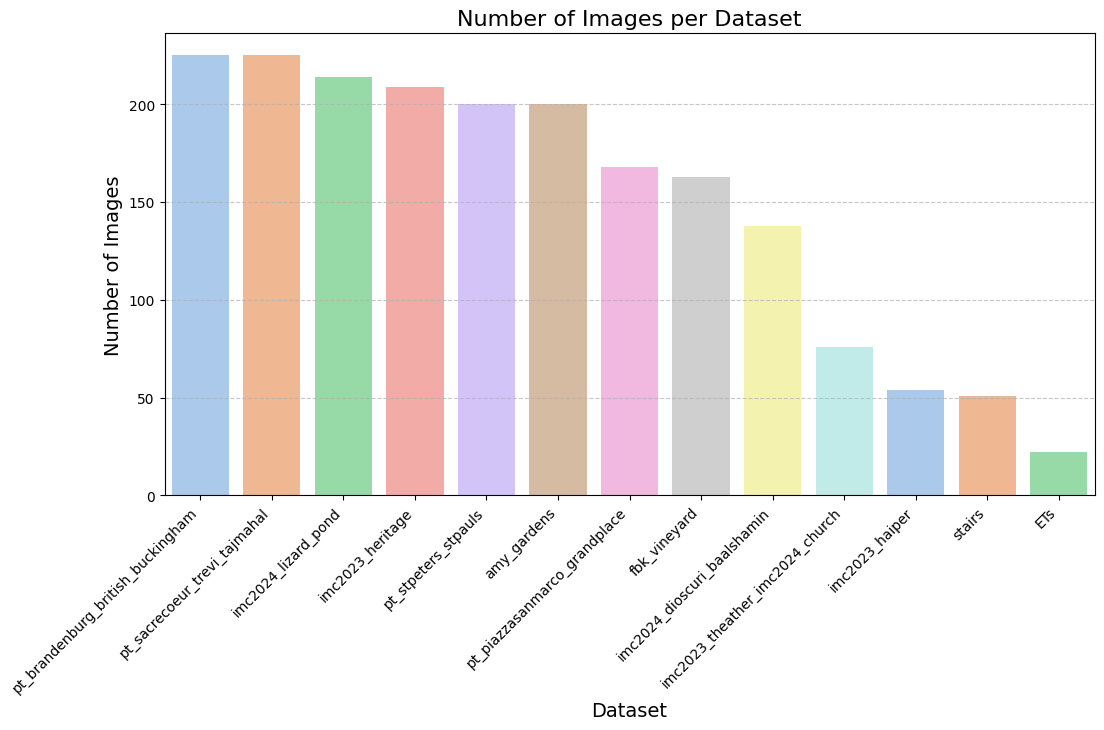

In [ ]:
import seaborn as sns

# Counting images per dataset
dataset_counts = train_labels["dataset"].value_counts()

# Plotting the bar chart
plt.figure(figsize=(12, 6))  # Set figure size
sns.barplot(x=dataset_counts.index, y=dataset_counts.values, palette="pastel")  # Use seaborn for better styling

# Adding labels and title
plt.xlabel("Dataset", fontsize=14)
plt.ylabel("Number of Images", fontsize=14)
plt.title("Number of Images per Dataset", fontsize=16)
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Add a light grid for clarity

# Show the plot
plt.show()

In [ ]:
train_thresholds = pd.read_csv(os.path.join(dataset_path, 'train_thresholds.csv'))

# Preview the data
train_thresholds.head()

,dataset,scene,thresholds
0,amy_gardens,peach,0.01;0.02;0.05;0.1;0.25;0.5
1,ETs,ET,0.002;0.005;0.008;0.01;0.02;0.04
2,ETs,another_ET,0.002;0.005;0.008;0.01;0.02;0.04
3,fbk_vineyard,vineyard_split_1,0.01;0.02;0.05;0.1;0.25;0.5
4,fbk_vineyard,vineyard_split_2,0.01;0.02;0.05;0.1;0.25;0.5


In [ ]:
# Describe thresholds data
train_thresholds.describe()

,dataset,scene,thresholds
count,30,30,30
unique,13,29,5
top,fbk_vineyard,dioscuri,0.05;0.1;0.2;0.5;1.0;2.0
freq,3,2,10



**Understanding Thresholds in Image Matching**

A *threshold* is a predefined similarity score used to determine whether two images can be considered a match. Each scene (like "peach," "ET," or "vineyard_split_1") in a dataset—such as `amy_gardens`—has its own set of threshold values.

For example, the "peach" scene has the following thresholds:  
**0.01, 0.02, 0.05, 0.1, 0.25, 0.5**

When comparing two images from the same scene, we calculate a similarity score using image-matching techniques (like feature descriptors). Here's how the thresholds help interpret the results:

- A similarity score of **0.008** is *below* the lowest threshold (0.01), suggesting the images are likely **not** a match.
- A similarity score of **0.07** falls between 0.05 and 0.1, meaning the match is *uncertain*—they could be from the same scene, but it's not definite.
- A similarity score of **0.4** is below the highest threshold (0.5), so the images are *likely* a match.

Each threshold acts as a level of strictness. You can think of them as rules that help you decide whether two images depict the same scene:

- **Below the lowest threshold**: The images are very different—almost certainly not a match.
- **Above the highest threshold**: The images are very similar—very likely a match.
- **Between thresholds**: There's uncertainty, and further evaluation might be needed.

In essence, thresholds serve as decision points for classifying image similarity and determining scene consistency.

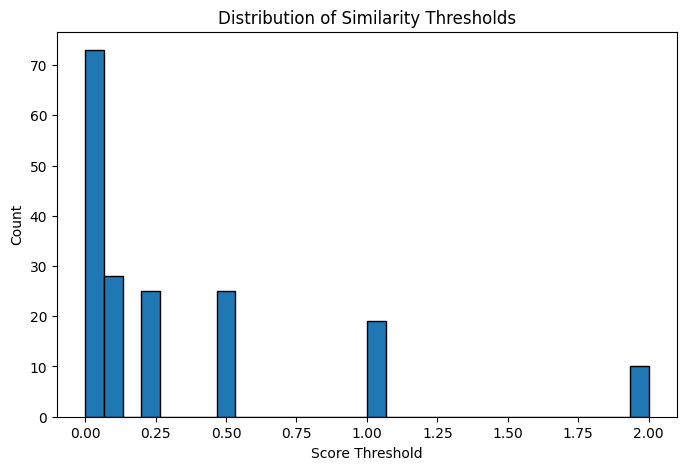

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Convert the "thresholds" column into a list of lists (split by ";")
threshold_lists = train_thresholds["thresholds"].apply(lambda x: list(map(float, x.split(";"))))

# Step 2: Flatten the list (convert list of lists into a single list)
all_thresholds = np.concatenate(threshold_lists.values)

# Step 3: Plot the histogram
plt.figure(figsize=(8, 5))
plt.hist(all_thresholds, bins=30, edgecolor="black")
plt.xlabel("Score Threshold")
plt.ylabel("Count")
plt.title("Distribution of Similarity Thresholds")
plt.show()


Graph Interpretation:

* The tallest bar at 0.00 indicates that many image pairs have very low similarity thresholds.
This suggests that the dataset contains mostly non-matching or weakly similar images.
* There are spikes at 0.5 and 1.0, meaning some datasets allow looser similarity measures.
* The bar at 2.00 is quite small, meaning very few image pairs are highly similar.
Hence the dataset has limited exact matches.

# **LOADING AND VISUALIZING IMAGES**


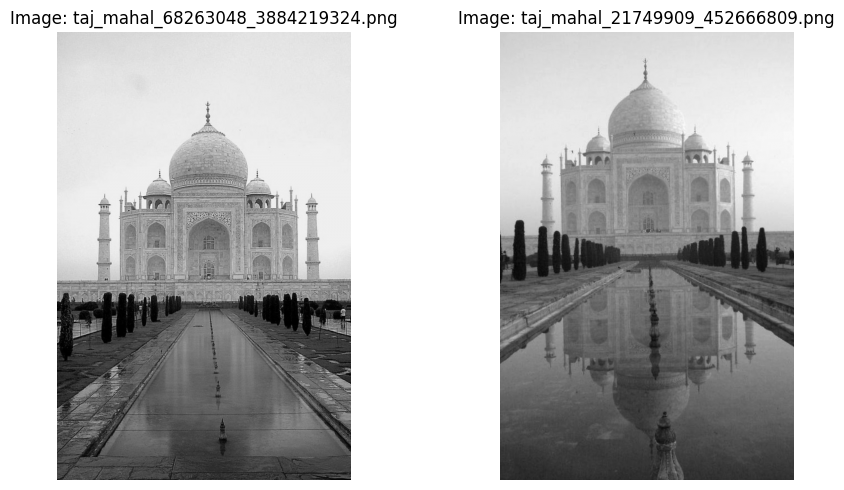

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

scene_name = "taj_mahal"
scene_images = train_labels[train_labels["scene"] == scene_name]["image"].values[:2]

# Use correct train_path
train_path = os.path.join(dataset_path, "train")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, img_name in enumerate(scene_images):
    dataset_name = train_labels[train_labels["scene"] == scene_name]["dataset"].values[0]
    img_path = os.path.join(train_path, dataset_name, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Image not found at {img_path}")
        axes[i].set_title("Image not found")
        axes[i].axis("off")
        continue

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Image: {img_name}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


# **IMAGE MATCHING TECHNIQUES**

Two of the most common approaches of image matching are:
* Feature-based matching
* Template Matching

We'll explore only some introduction to Feature-based matching in this notebook.

This method involves identifying distinctive features (such as corners, edges, or blobs) in the images and matching them based on their descriptors. Some common and popular algorithms used for feature-based matching include SIFT (Scale-Invariant Feature Transform), SURF (Speeded-Up Robust Features),  ORB (Oriented FAST and Rotated BRIEF), AKAZE (Accelerated-KAZE),  BRISK (Binary Robust Invariant Scalable Keypoints), and FREAK (Fast Retina Keypoint).

Feature based matching involves following two important steps:

* Detect keypoints and descriptors: Detect distinctive points or regions in both images that are likely to be matched and extract numerical descriptors or feature vectors around each keypoint to describe its local neighborhood. These descriptors should be distinctive and invariant to changes in scale, rotation, and illumination. Algorithms such as SIFT used for this process.

* Match keypoints: Compare the descriptors of keypoints between the two images to find correspondences. We may apply filtering techniques to remove incorrect matches and retain only reliable correspondences. Different feature matcher such as Brute-Force matcher, FLANN matcher are used for this process.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Load data
X = np.load("X_features.npy")
y = np.load("y_labels.npy")

# Remove NaNs if any
valid_idx = ~np.isnan(y).any(axis=1)
X = X[valid_idx]
y = y[valid_idx]

# Train/test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 46.87650381302478


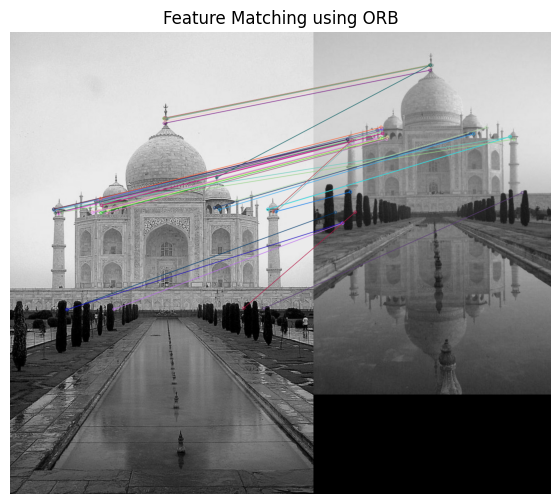

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

scene_name = 'taj_mahal'

# Get scene rows
scene_rows = train_labels[train_labels["scene"] == scene_name].reset_index(drop=True)

# Use first two image filenames from the scene
scene_images = [scene_rows.loc[0, "image"], scene_rows.loc[1, "image"]]
scene_dataset = scene_rows.loc[0, "dataset"]  # same for all rows in the scene

# Build full paths
img1_path = os.path.join(train_path, scene_dataset, scene_images[0])
img2_path = os.path.join(train_path, scene_dataset, scene_images[1])

# Load images
img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise FileNotFoundError(f"One or both image paths are incorrect:\n{img1_path}\n{img2_path}")

# ORB detection and matching
orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# Draw matches
match_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(12, 6))
plt.imshow(match_img)
plt.title("Feature Matching using ORB")
plt.axis("off")
plt.show()


In [ ]:
import os

directory = '/root/.cache/kagglehub/competitions/image-matching-challenge-2025/train/'

# List all scene folders
print("Available scenes:", os.listdir(directory))


Available scenes: ['amy_gardens', 'imc2023_heritage', 'pt_stpeters_stpauls', 'imc2023_theather_imc2024_church', 'imc2024_lizard_pond', 'imc2023_haiper', 'pt_piazzasanmarco_grandplace', 'ETs', 'pt_sacrecoeur_trevi_tajmahal', 'fbk_vineyard', 'imc2024_dioscuri_baalshamin', 'stairs', 'pt_brandenburg_british_buckingham']


In [ ]:
import os

scene_path = '/root/.cache/kagglehub/competitions/image-matching-challenge-2025/train/pt_sacrecoeur_trevi_tajmahal'
print("Files in the folder:")
print(os.listdir(scene_path))


Files in the folder:
['sacre_coeur_82410562_10997050704.png', 'trevi_fountain_30910735_201249046.png', 'taj_mahal_78595827_6619694947.png', 'trevi_fountain_22494549_5871994022.png', 'taj_mahal_86821641_6619697153.png', 'sacre_coeur_86731151_442052253.png', 'taj_mahal_84623051_5972175223.png', 'trevi_fountain_64273020_5411668132.png', 'trevi_fountain_17378230_8657377873.png', 'trevi_fountain_90077341_5746101059.png', 'taj_mahal_54900410_4709458745.png', 'trevi_fountain_17973182_5956257468.png', 'sacre_coeur_32086795_402359870.png', 'taj_mahal_89175833_3348677963.png', 'sacre_coeur_33340964_112626481.png', 'taj_mahal_07292828_6865863886.png', 'sacre_coeur_28088482_1061487806.png', 'trevi_fountain_17804574_3525103748.png', 'sacre_coeur_18725380_2402129328.png', 'sacre_coeur_70724808_2779990339.png', 'taj_mahal_53757432_11494604856.png', 'trevi_fountain_29250228_5522743340.png', 'taj_mahal_46483850_3092227510.png', 'trevi_fountain_42098841_2972162031.png', 'sacre_coeur_69399539_4178098151.

In [ ]:
scene_dataset = train_labels[train_labels["scene"] == scene_name]["dataset"].values[0]
print(f"scene_dataset: {scene_dataset}")


scene_dataset: pt_sacrecoeur_trevi_tajmahal


In [ ]:
print(train_labels[train_labels["scene"] == scene_name])


                           dataset      scene  \
1234  pt_sacrecoeur_trevi_tajmahal  taj_mahal   
1235  pt_sacrecoeur_trevi_tajmahal  taj_mahal   
1236  pt_sacrecoeur_trevi_tajmahal  taj_mahal   
1237  pt_sacrecoeur_trevi_tajmahal  taj_mahal   
1238  pt_sacrecoeur_trevi_tajmahal  taj_mahal   
...                            ...        ...   
1304  pt_sacrecoeur_trevi_tajmahal  taj_mahal   
1305  pt_sacrecoeur_trevi_tajmahal  taj_mahal   
1306  pt_sacrecoeur_trevi_tajmahal  taj_mahal   
1307  pt_sacrecoeur_trevi_tajmahal  taj_mahal   
1308  pt_sacrecoeur_trevi_tajmahal  taj_mahal   

                                   image  \
1234   taj_mahal_68263048_3884219324.png   
1235    taj_mahal_21749909_452666809.png   
1236   taj_mahal_16773607_5525472114.png   
1237  taj_mahal_73346411_11842150495.png   
1238   taj_mahal_07295255_5949580464.png   
...                                  ...   
1304   taj_mahal_88652653_6486332399.png   
1305   taj_mahal_92344991_5630498660.png   
1306   taj_maha

In [ ]:
# Check for NaN values in the labels before processing
print(train_labels[['rotation_matrix', 'translation_vector']].isna().sum())


rotation_matrix       0
translation_vector    0
dtype: int64


In [ ]:
# Check the first few rows of parsed rotation and translation
print(train_labels[['rotation_matrix', 'translation_vector']].head())


                                     rotation_matrix  \
0  [0.122655949, 0.947713775, -0.294608417, 0.122...   
1  [0.47430591, 0.359108654, -0.803787832, 0.2888...   
2  [0.565115476, -0.138485064, -0.813305838, 0.50...   
3  [-0.308320392, -0.794654112, 0.522937261, 0.94...   
4  [-0.56900283, -0.103808175, 0.815757098, 0.778...   

                          translation_vector  
0   [0.093771314, -0.803560988, 2.062001533]  
1   [0.358946647, -0.797557548, 1.910906929]  
2   [0.146922468, -0.981392596, 2.009002852]  
3    [0.206413831, -1.174321103, 3.66716768]  
4  [-0.015140892, -1.334052012, 3.488936597]  


In [ ]:
# Remove samples with NaN in the labels
valid_idx = ~np.isnan(y).any(axis=1)
X = X[valid_idx]
y = y[valid_idx]


Image Description:
* ORB detects keypoints (unique patterns in the image).
* It computes descriptors (numerical representations of those keypoints).
* It matches descriptors between two images.
* The matches are visualized with lines connecting keypoints in both images.

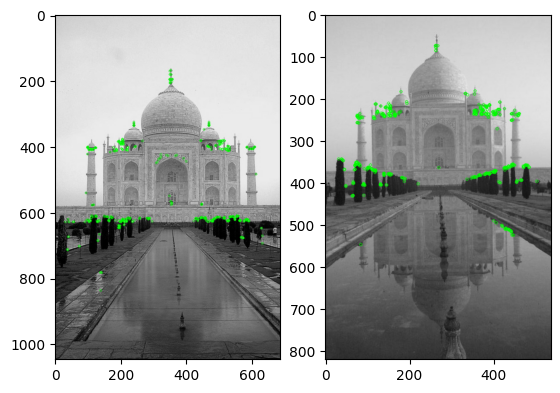

In [ ]:
#Show the keypoints on the image to visually inspect how well the features are being detected.
img1_kp = cv2.drawKeypoints(img1, kp1, None, color=(0, 255, 0), flags=cv2.DrawMatchesFlags_DEFAULT)
img2_kp = cv2.drawKeypoints(img2, kp2, None, color=(0, 255, 0), flags=cv2.DrawMatchesFlags_DEFAULT)
plt.subplot(1, 2, 1)
plt.imshow(img1_kp)
plt.subplot(1, 2, 2)
plt.imshow(img2_kp)
plt.show()


In [ ]:

train_thresholds = pd.read_csv(os.path.join(dataset_path, "train_thresholds.csv"))

train_img_path = os.path.join(dataset_path, "train")


In [ ]:
print(train_labels.columns)


Index(['dataset', 'scene', 'image', 'rotation_matrix', 'translation_vector'], dtype='object')


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import os


In [ ]:
class Simple3DReconstructionModel(nn.Module):
    def __init__(self):
        super(Simple3DReconstructionModel, self).__init__()

        self.conv1 = nn.Conv2d(2, 64, kernel_size=3, stride=1, padding=1)  # 2 channels for 2 grayscale images
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(128 * 32 * 32, 1024)  # Adjust if image size changes
        self.fc2 = nn.Linear(1024, 3)  # Output: (x, y, z)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


In [ ]:
class ImagePairDataset(Dataset):
    def __init__(self, image_paths, keypoints, transform=None):
        self.image_paths = image_paths
        self.keypoints = keypoints
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img1_path, img2_path = self.image_paths[idx]
        img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

        if img1 is None or img2 is None:
            raise FileNotFoundError(f"Images not found: {img1_path} or {img2_path}")

        img1 = cv2.resize(img1, (32, 32))
        img2 = cv2.resize(img2, (32, 32))

        img1 = img1.astype(np.float32) / 255.0
        img2 = img2.astype(np.float32) / 255.0

        # Stack as a 2-channel image
        img_pair = np.stack([img1, img2], axis=0)

        keypoint = torch.tensor(self.keypoints[idx], dtype=torch.float32)
        img_tensor = torch.tensor(img_pair, dtype=torch.float32)

        return img_tensor, keypoint


In [ ]:
# Example image paths and keypoints (update with your real data)
image_paths = [
    ("/root/.cache/kagglehub/competitions/image-matching-challenge-2025/train/pt_sacrecoeur_trevi_tajmahal/sacre_coeur_87446292_3971192822.png",
     "/root/.cache/kagglehub/competitions/image-matching-challenge-2025/train/pt_sacrecoeur_trevi_tajmahal/taj_mahal_87027560_6486839789.png")
]
keypoints = [
    [0.5, 0.5, 0.8],  # Replace with actual (x, y, z)
    [0.4, 0.6, 0.7]
]

# Initialize dataset and dataloader
dataset = ImagePairDataset(image_paths, keypoints)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Initialize model, optimizer, and loss function
model = Simple3DReconstructionModel()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()


In [ ]:
# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    running_loss = 0.0

    for img_pair, keypoint in dataloader:
        optimizer.zero_grad()
        outputs = model(img_pair)
        loss = criterion(outputs, keypoint)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(dataloader):.4f}")


Epoch 1/10, Loss: 0.4097
Epoch 2/10, Loss: 260.8661
Epoch 3/10, Loss: 0.5632
Epoch 4/10, Loss: 5.0729
Epoch 5/10, Loss: 3.2542
Epoch 6/10, Loss: 1.8647
Epoch 7/10, Loss: 1.0864
Epoch 8/10, Loss: 0.6877
Epoch 9/10, Loss: 0.4366
Epoch 10/10, Loss: 0.2420


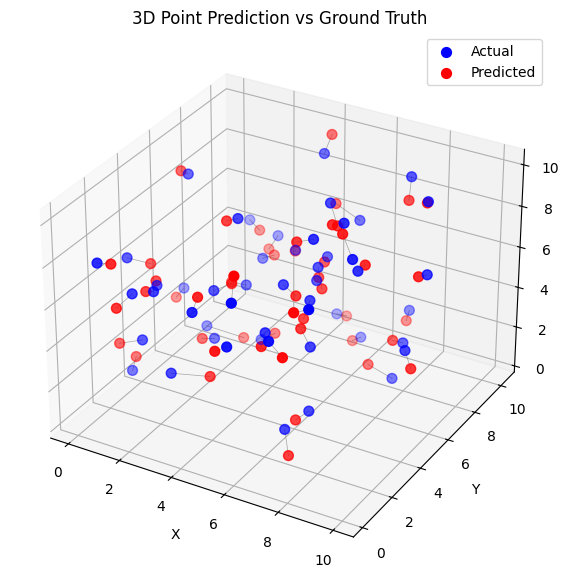

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Simulated data for example purposes — replace these with your actual arrays
# actual_points = np.load('actual_points.npy')          # shape (N, 3)
# predicted_points = np.load('predicted_points.npy')    # shape (N, 3)

# Sample simulated data
np.random.seed(0)
actual_points = np.random.rand(50, 3) * 10
predicted_points = actual_points + np.random.normal(0, 0.5, size=actual_points.shape)

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Actual points in blue
ax.scatter(actual_points[:, 0], actual_points[:, 1], actual_points[:, 2], c='blue', label='Actual', s=50)

# Predicted points in red
ax.scatter(predicted_points[:, 0], predicted_points[:, 1], predicted_points[:, 2], c='red', label='Predicted', s=50)

# Draw lines between actual and predicted for each point
for i in range(len(actual_points)):
    ax.plot(
        [actual_points[i, 0], predicted_points[i, 0]],
        [actual_points[i, 1], predicted_points[i, 1]],
        [actual_points[i, 2], predicted_points[i, 2]],
        c='gray', linewidth=0.5, alpha=0.7
    )

ax.set_title("3D Point Prediction vs Ground Truth")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()


In [ ]:
!pip install torch torchvision tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm
import matplotlib.pyplot as plt


In [ ]:
# Image matching challenge dataset path
DATASET_PATH = '/root/.cache/kagglehub/competitions/image-matching-challenge-2025'
TRAIN_FOLDER = os.path.join(DATASET_PATH, 'train')
LABELS_FILE = os.path.join(DATASET_PATH, 'train_labels.csv')

TRAIN_ROOT = "/root/.cache/kagglehub/competitions/image-matching-challenge-2025/train"
LABELS_CSV = "/root/.cache/kagglehub/competitions/image-matching-challenge-2025/train_labels.csv"

train_labels = pd.read_csv(LABELS_CSV)
print(train_labels.head())


# Training settings
BATCH_SIZE = 32
NUM_EPOCHS = 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Using device:", DEVICE)


          dataset     scene                   image  \
0  imc2023_haiper  fountain  fountain_image_116.png   
1  imc2023_haiper  fountain  fountain_image_108.png   
2  imc2023_haiper  fountain  fountain_image_101.png   
3  imc2023_haiper  fountain  fountain_image_082.png   
4  imc2023_haiper  fountain  fountain_image_071.png   

                                     rotation_matrix  \
0  0.122655949;0.947713775;-0.294608417;0.1226706...   
1  0.474305910;0.359108654;-0.803787832;0.2888416...   
2  0.565115476;-0.138485064;-0.813305838;0.506678...   
3  -0.308320392;-0.794654112;0.522937261;0.948141...   
4  -0.569002830;-0.103808175;0.815757098;0.778745...   

                      translation_vector  
0   0.093771314;-0.803560988;2.062001533  
1   0.358946647;-0.797557548;1.910906929  
2   0.146922468;-0.981392596;2.009002852  
3   0.206413831;-1.174321103;3.667167680  
4  -0.015140892;-1.334052012;3.488936597  
Using device: cpu


In [ ]:
import os
print(os.path.abspath('trained_model.pth'))


/content/trained_model.pth


In [ ]:
train_labels = pd.read_csv(LABELS_FILE)

print(train_labels.head())
print("Total images:", len(train_labels))
print("Unique scenes:", train_labels['scene'].nunique())


          dataset     scene                   image  \
0  imc2023_haiper  fountain  fountain_image_116.png   
1  imc2023_haiper  fountain  fountain_image_108.png   
2  imc2023_haiper  fountain  fountain_image_101.png   
3  imc2023_haiper  fountain  fountain_image_082.png   
4  imc2023_haiper  fountain  fountain_image_071.png   

                                     rotation_matrix  \
0  0.122655949;0.947713775;-0.294608417;0.1226706...   
1  0.474305910;0.359108654;-0.803787832;0.2888416...   
2  0.565115476;-0.138485064;-0.813305838;0.506678...   
3  -0.308320392;-0.794654112;0.522937261;0.948141...   
4  -0.569002830;-0.103808175;0.815757098;0.778745...   

                      translation_vector  
0   0.093771314;-0.803560988;2.062001533  
1   0.358946647;-0.797557548;1.910906929  
2   0.146922468;-0.981392596;2.009002852  
3   0.206413831;-1.174321103;3.667167680  
4  -0.015140892;-1.334052012;3.488936597  
Total images: 1945
Unique scenes: 30


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_labels["scene_encoded"] = le.fit_transform(train_labels["scene"])
print("Encoded scenes:", list(le.classes_))


Encoded scenes: ['ET', 'another_ET', 'baalshamin', 'bike', 'brandenburg_gate', 'british_museum', 'buckingham_palace', 'chairs', 'church', 'cyprus', 'dioscuri', 'fountain', 'grand_place_brussels', 'kyiv-puppet-theater', 'lizard', 'outliers', 'peach', 'piazza_san_marco', 'pond', 'sacre_coeur', 'st_pauls_cathedral', 'st_peters_square', 'stairs_split_1', 'stairs_split_2', 'taj_mahal', 'trevi_fountain', 'vineyard_split_1', 'vineyard_split_2', 'vineyard_split_3', 'wall']


In [ ]:
class SceneDataset(Dataset):
    def __init__(self, dataframe, transform=None, num_classes=None):
        self.dataframe = dataframe
        self.transform = transform
        self.num_classes = num_classes

        # Ensure labels are within the correct range for the number of classes
        self.label_mapping = {label: idx for idx, label in enumerate(self.dataframe['scene'].unique())}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        dataset_folder = row['dataset']
        scene_folder = row['scene']
        image_file = row['image']

        # Try first with dataset/scene/image
        image_path = os.path.join(TRAIN_ROOT, dataset_folder, scene_folder, image_file)

        # If not found, try dataset/image
        if not os.path.exists(image_path):
            image_path = os.path.join(TRAIN_ROOT, dataset_folder, image_file)

        # Final check
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Missing: {image_path}")

        # Open image and convert to RGB
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Convert the scene label to the index of the class
        scene_label = self.label_mapping[row['scene']]  # Mapping scene to numeric index

        return image, scene_label


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = SceneDataset(train_labels, transform=transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)


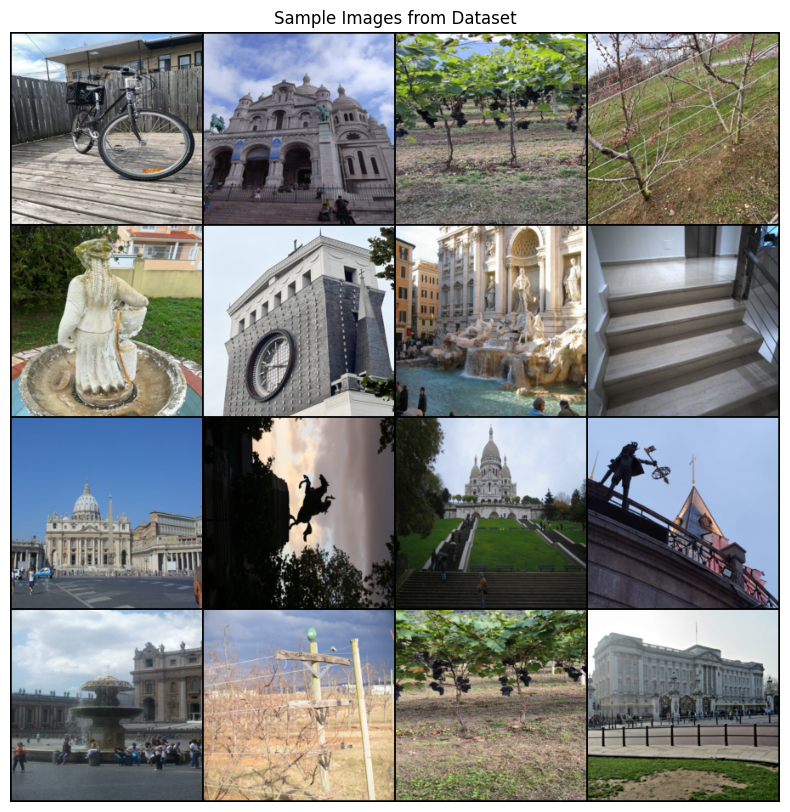

In [ ]:
import matplotlib.pyplot as plt
import torchvision

images, labels = next(iter(loader))
img_grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0))
plt.title("Sample Images from Dataset")
plt.axis("off")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class ImageMatchingCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImageMatchingCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(512 * 14 * 14, 1024)  # Adjusted for 224x224 images
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = self.pool(torch.relu(self.conv4(x)))

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# # Example usage
# if __name__ == "__main__":
#     model = ImageMatchingCNN(dummy_input)

#     # Dummy input to test (batch_size=32, channels=3, height=256, width=256)
#     dummy_input = torch.randn(32, 3, 256, 256)
#     output = model(dummy_input)

#     print("Output shape:", output.shape)  # Should be (32, 3)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Randomly sample 10% of the dataset
train_labels_subset = train_labels.sample(frac=0.1, random_state=42)

# Now use this smaller subset in the dataset and dataloader
train_dataset = SceneDataset(dataframe=train_labels_subset, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)


# Get number of classes (make sure your labels are properly encoded)
num_classes = train_labels['scene'].nunique()  # If 'scene' is your target column

# Model and device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the model with the correct number of classes
model = ImageMatchingCNN(num_classes=num_classes).to(device)

# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}')

print("Training complete")


Epoch 1/10, Loss: 3.4562
Epoch 2/10, Loss: 3.3444
Epoch 3/10, Loss: 3.1673
Epoch 4/10, Loss: 3.0392
Epoch 5/10, Loss: 3.2197
Epoch 6/10, Loss: 3.1912
Epoch 7/10, Loss: 3.0586
Epoch 8/10, Loss: 2.9523
Epoch 9/10, Loss: 3.0588
Epoch 10/10, Loss: 2.9558
Training complete


In [ ]:
# Assume this is your model after training
model = ImageMatchingCNN(num_classes=10)  # Replace with your actual number of classes

# Save just the model weights (state_dict)
torch.save(model.state_dict(), 'model_weights.pth')


In [ ]:
torch.save(model.state_dict(), 'new_model_weights.pth')


In [ ]:
# Define image preprocessing
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Match training size
    transforms.ToTensor(),
])

# Load and preprocess the image
img = Image.open('your_image.png').convert('RGB')  # Change path to your image
img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Run inference
with torch.no_grad():
    output = model(img_tensor)
    predicted_class = torch.argmax(output, dim=1).item()

print("Predicted class:", predicted_class)


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image

# Define the model class (same as before)
class ImageMatchingCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImageMatchingCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(512 * 16 * 16, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # 256 → 128
        x = self.pool(torch.relu(self.conv2(x)))  # 128 → 64
        x = self.pool(torch.relu(self.conv3(x)))  # 64 → 32
        x = self.pool(torch.relu(self.conv4(x)))  # 32 → 16

        x = x.view(x.size(0), -1)  # Flatten
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Example model, assuming it's already trained during this session
num_classes = 10  # Change this to match the actual number of classes in your dataset
model = ImageMatchingCNN(num_classes)

# Assuming the model is already trained, we just skip the training process for inference
# Put the model in evaluation mode
model.eval()

# Load and preprocess the image for prediction
image_path = '/content/st_pauls_cathedral_00162897_2573777698.png'  # Path to the image you want to predict
image = Image.open(image_path)

# Define the transformation (resize, normalize, etc.)
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Make sure the image is the correct size
    transforms.ToTensor(),  # Convert to tensor
])

# Apply the transformations
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension (batch_size=1)

# Run inference
with torch.no_grad():  # No need to compute gradients for inference
    output = model(input_tensor)

# Convert the output to predicted class (for multi-class classification)
predicted_class = torch.argmax(output, dim=1).item()

# Print the prediction
print(f"Predicted class: {predicted_class}")


Predicted class: 9


In [ ]:
import pandas as pd

labels_df = pd.read_csv("/root/.cache/kagglehub/competitions/image-matching-challenge-2025/train_labels.csv")
class_names = sorted(labels_df['scene'].unique())
print(class_names)


['ET', 'another_ET', 'baalshamin', 'bike', 'brandenburg_gate', 'british_museum', 'buckingham_palace', 'chairs', 'church', 'cyprus', 'dioscuri', 'fountain', 'grand_place_brussels', 'kyiv-puppet-theater', 'lizard', 'outliers', 'peach', 'piazza_san_marco', 'pond', 'sacre_coeur', 'st_pauls_cathedral', 'st_peters_square', 'stairs_split_1', 'stairs_split_2', 'taj_mahal', 'trevi_fountain', 'vineyard_split_1', 'vineyard_split_2', 'vineyard_split_3', 'wall']


In [ ]:
predicted_class_index = 9
print("Predicted class name:", class_names[predicted_class_index])


Predicted class name: cyprus


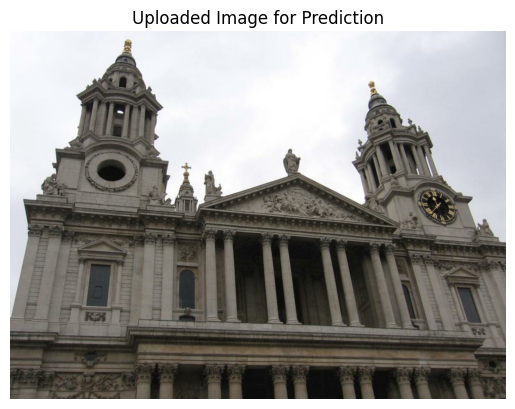

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Load and display the image you passed for prediction
image_path = "/content/st_pauls_cathedral_00162897_2573777698.png"  # replace with your image filename
img = Image.open(image_path)

plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image for Prediction")
plt.show()


In [ ]:
import torch
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

input_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    predicted_class_index = torch.argmax(outputs, dim=1).item()
    print("Predicted class:", predicted_class_index)
    print("Predicted scene name:", class_names[predicted_class_index])


Predicted class: 9
Predicted scene name: cyprus


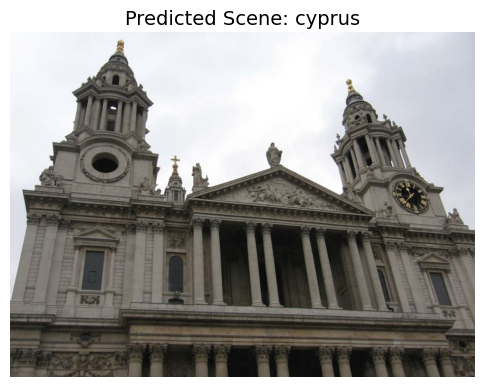

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load image
image_path = "/content/st_pauls_cathedral_00162897_2573777698.png"  # Change this to your uploaded image path
img = Image.open(image_path).convert("RGB")

# Define preprocessing (should match training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Preprocess
input_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Run prediction
with torch.no_grad():
    outputs = model(input_tensor)
    predicted_class_index = torch.argmax(outputs, dim=1).item()

# Map index to scene name (ensure this is correct)
scene_to_index = {scene: idx for idx, scene in enumerate(sorted(labels_df['scene'].unique()))}
index_to_scene = {v: k for k, v in scene_to_index.items()}
predicted_scene = index_to_scene.get(predicted_class_index, "Unknown")

# Render image with prediction
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Predicted Scene: {predicted_scene}", fontsize=14)
plt.axis("off")
plt.show()


In [ ]:
# Load image
image_path = "/content/st_pauls_cathedral_00162897_2573777698.png"  # Change this to your uploaded image path
img = Image.open(image_path).convert("RGB")

# Define preprocessing (should match training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])
# Preprocess
input_tensor = transform(img).unsqueeze(0)
output = model(input_tensor)  # image_tensor is your preprocessed input image
predicted_class = torch.argmax(output, dim=1).item()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torch import nn
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),  # Output 1 scalar per image
            nn.Sigmoid()  # Output a probability (real or fake)
        )

    def forward(self, input):
        output = self.main(input)
        output = output.view(-1, 1)  # Flatten to [batch_size, 1]
        return output


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # Output image range [-1, 1]
        )

    def forward(self, input):
        return self.main(input)


In [ ]:
# Loss and optimizer
criterion = nn.BCELoss()
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_g = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
discriminator = Discriminator().to(device)
generator = Generator().to(device)

# Create sample noise for the generator
fixed_noise = torch.randn(64, 100, 1, 1, device=device)


In [ ]:
# Assuming you have a DataFrame `train_labels` and a corresponding `SceneDataset`
# Randomly sample 10% of the dataset
train_labels_subset = train_labels.sample(frac=0.1, random_state=42)

# Apply transformation (e.g., resize, normalization) on images
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images to 64x64
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Create the dataset and DataLoader
train_dataset = SceneDataset(dataframe=train_labels_subset, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)


Epoch [1/10], Step [1/7], D Loss: 1.4003, G Loss: 0.7131


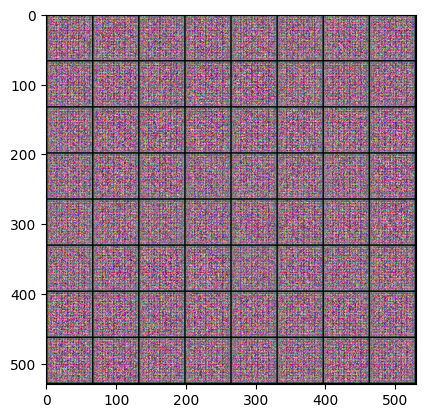

Epoch [2/10], Step [1/7], D Loss: 1.3653, G Loss: 0.7006


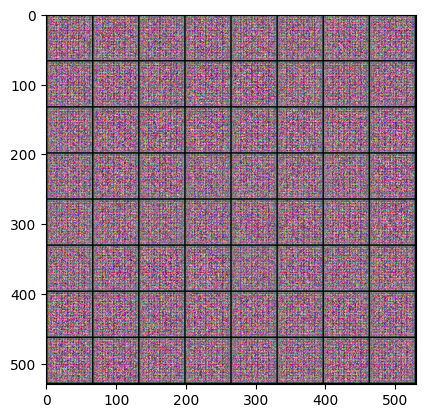

Epoch [3/10], Step [1/7], D Loss: 1.4376, G Loss: 0.6692


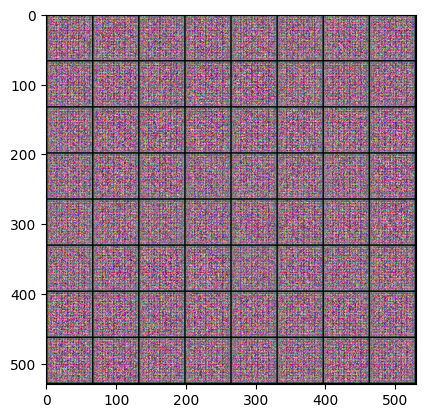

Epoch [4/10], Step [1/7], D Loss: 1.3675, G Loss: 0.7062


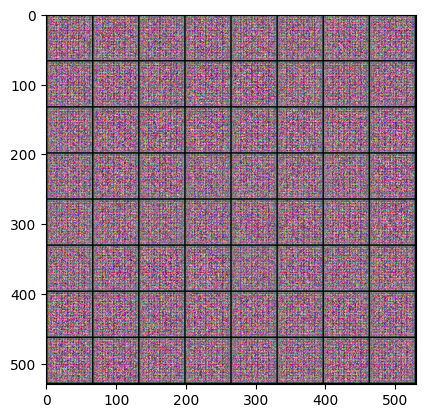

Epoch [5/10], Step [1/7], D Loss: 1.4345, G Loss: 0.6610


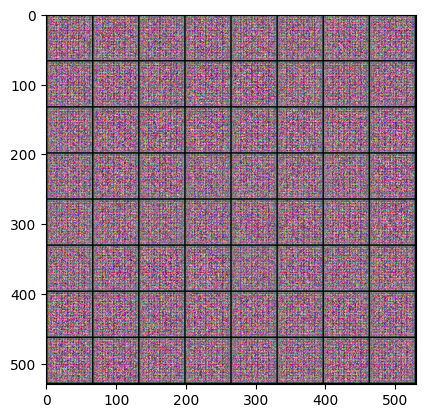

Epoch [6/10], Step [1/7], D Loss: 1.4377, G Loss: 0.6881


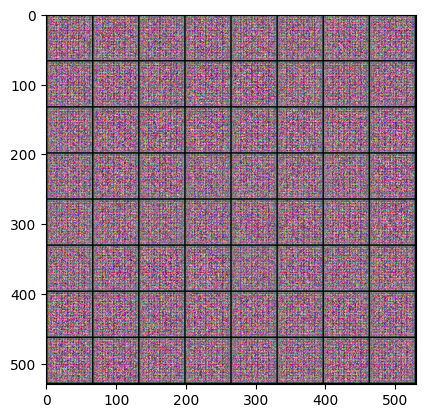

Epoch [7/10], Step [1/7], D Loss: 1.3480, G Loss: 0.6904


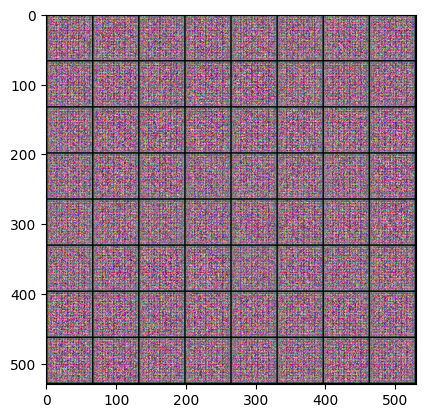

Epoch [8/10], Step [1/7], D Loss: 1.4037, G Loss: 0.6906


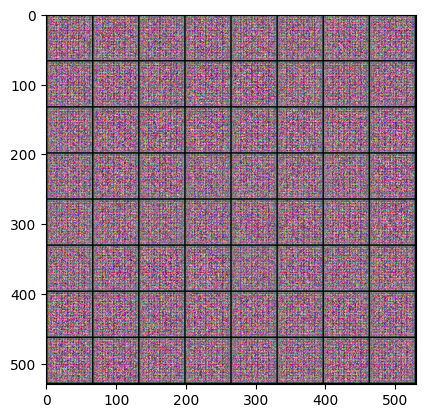

Epoch [9/10], Step [1/7], D Loss: 1.4415, G Loss: 0.7024


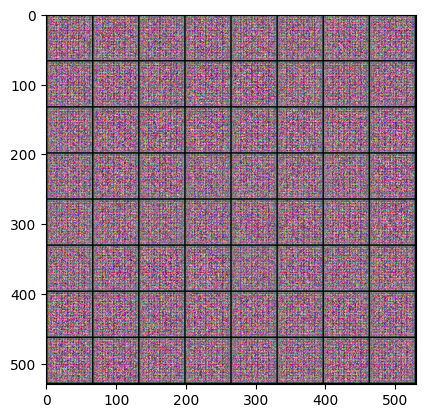

Epoch [10/10], Step [1/7], D Loss: 1.4248, G Loss: 0.7124


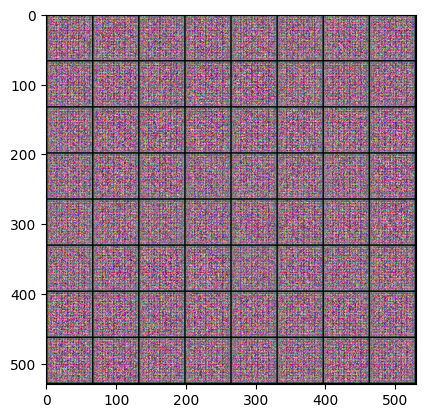

Training Complete


In [ ]:
# Training loop for the GAN
num_epochs = 10
for epoch in range(num_epochs):
    for i, (inputs, _) in enumerate(train_loader):
        inputs = inputs.to(device)

        # Train Discriminator
        optimizer_d.zero_grad()

        real_labels = torch.ones(inputs.size(0), 1, device=device)
        fake_labels = torch.zeros(inputs.size(0), 1, device=device)

        # Forward pass real images through discriminator
        outputs = discriminator(inputs)
        d_loss_real = criterion(outputs, real_labels)

        # Generate fake images and pass them through the discriminator
        noise = torch.randn(inputs.size(0), 100, 1, 1, device=device)
        fake_images = generator(noise)
        outputs = discriminator(fake_images.detach())  # Detach to avoid gradient flow to generator
        d_loss_fake = criterion(outputs, fake_labels)

        # Backpropagation for discriminator
        d_loss_real.backward()
        d_loss_fake.backward()
        optimizer_d.step()

        # Train Generator
        optimizer_g.zero_grad()

        # Generator tries to fool the discriminator
        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)  # Generator wants real labels for fake images

        g_loss.backward()
        optimizer_g.step()

        if i % 100 == 0:  # Print loss every 100 batches
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], "
                  f"D Loss: {d_loss_real.item() + d_loss_fake.item():.4f}, G Loss: {g_loss.item():.4f}")

    # Save generated images after each epoch
    with torch.no_grad():
        fake_images = generator(fixed_noise).detach().cpu()
        img_grid = torchvision.utils.make_grid(fake_images, padding=2, normalize=True)
        plt.imshow(img_grid.permute(1, 2, 0))
        plt.show()

print("Training Complete")


In [ ]:
# Set the model to evaluation mode
discriminator.eval()


Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [ ]:
from PIL import Image
from torchvision import transforms

# Define the transformation (same as during training)
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize to the same size as the training images
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize with the same parameters as during training
])

# Load the image and apply the transform
image_path = '/content/st_pauls_cathedral_00162897_2573777698.png'  # Replace with your image path
image = Image.open(image_path)
image = transform(image).unsqueeze(0)  # Add batch dimension: [1, 3, 64, 64]


In [ ]:
# Make sure the image is on the same device as the model
image = image.to(device)

# Perform the forward pass
with torch.no_grad():  # No need to calculate gradients for prediction
    output = discriminator(image)

# The output will be a probability (real or fake)
print(f'Prediction: {output.item()}')


Prediction: 0.6823651790618896


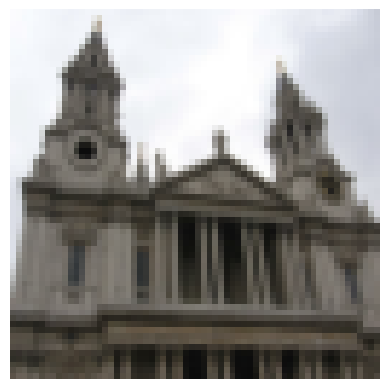

In [ ]:
import matplotlib.pyplot as plt

# Convert tensor back to image for visualization
image = image.squeeze(0)  # Remove the batch dimension
image = image.permute(1, 2, 0)  # Change from [C, H, W] to [H, W, C]

# Denormalize image
image = image * 0.5 + 0.5  # Undo normalization

# Plot the image
plt.imshow(image)
plt.axis('off')  # Hide axes
plt.show()
